In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
import pandas as pd
from scipy.optimize import curve_fit

from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from flatness import *

import tifffile as tiff


In [160]:
def beam_centroid(img,):
    # coordinate grids
    y, x = np.indices(img.shape)

    I = img.astype(float)

    total_intensity = np.nansum(I)

    if total_intensity == 0:
        return None, None  # or fallback to max pixel

    x_centroid = np.nansum(I * x) / total_intensity
    y_centroid = np.nansum(I * y) / total_intensity


    return int(x_centroid), int(y_centroid)

def beam_area_mask(img, fraction, cx,cy):
    peak_val = np.nanmax(img)
    threshold = fraction * peak_val

    # mask of pixels above threshold
    mask = img >= threshold

    return mask

def plot_dose1(dosemap, im_type):
    h, w = dosemap.shape
    strip_width = 10

    if im_type == 'RCF':
        pixel_calibration = 0.08467  # mm/pixel
    elif im_type == "YAG":
        pixel_calibration = 27.9/ (1680-800)
    else:
        raise ValueError("Unknown im_type")

    # Beam centroid in pixel coordinates
    cx, cy = beam_centroid(dosemap)

    # Centered physical coordinates in mm
    x = (np.arange(w) - cx) * pixel_calibration
    y = (np.arange(h) - cy) * pixel_calibration

    # Use integer indices for slicing
    row0 = max(0, cy - strip_width // 2)
    row1 = min(h, cy + strip_width // 2)
    col0 = max(0, cx - strip_width // 2)
    col1 = min(w, cx + strip_width // 2)

    slice_row = np.mean(dosemap[row0:row1, :], axis=0)
    slice_col = np.mean(dosemap[:, col0:col1], axis=1)

    fig, ax_main = plt.subplots(figsize=(10, 6))

    # Image centered at (0, 0)
    im = ax_main.imshow(
        dosemap,
        origin="lower",
        aspect="equal",
        cmap="viridis",
        extent=[x[0], x[-1], y[0], y[-1]]
    )

    # Beam mask and contour
    mask = beam_area_mask(dosemap, 0.85, cx, cy)
    # if im_type == 'YAG':
        # ax_main.contour(x, y, mask.astype(float), levels=[0.5], colors='white', linewidths=1.6)

    ax_main.set_xlabel("X (mm)")
    ax_main.set_ylabel("Y (mm)")

    # Axes for slices and colorbar
    divider = make_axes_locatable(ax_main)
    ax_x = divider.append_axes("top", size="25%", pad=0.1, sharex=ax_main)
    ax_y = divider.append_axes("right", size="20%", pad=0.1, sharey=ax_main)
    cax  = divider.append_axes("right", size="2%", pad=0.1)

    # Fit the slices
    p0 = [np.max(slice_row)/2, 0, 3, 2]
    p00 = [np.max(slice_row),  4, 2]


    params_x, _ = curve_fit(supergaussian1D, x, slice_row, p0=p0)
    params_y, _ = curve_fit(supergaussian1D, y, slice_col, p0=p0)

    params_xx, _ = curve_fit(sum_2gaussians, x, slice_row, p0=p00)
    params_yy, _ = curve_fit(sum_2gaussians, y, slice_col, p0=p00)

    sig_x, sig_y = params_x[2], params_y[2]
    P_x, P_y = params_x[3], params_y[3]
    r90_x, r90_y = r90(sig_x, P_x), r90(sig_y, P_y)

    # Top plot: X slice
    ax_x.plot(x, slice_row, 'k-', linewidth=3,)
    ax_x.plot( x,supergaussian1D(x, *params_x),  'r-',label=f"SuperGaussian Fit (P={params_x[3]:.2f}, r90={r90_x:.2f})")
    ax_x.plot(x, sum_2gaussians(x, *params_xx), 'g-', label=f"2-Gaussian Fit (x0/sigma={abs(params_xx[1])/params_xx[2]:.2f})")
    if im_type == 'YAG':
        ax_x.set_ylabel("Intensity")
    elif im_type == 'RCF':
        ax_x.set_ylabel("Relative Dose")
    ax_x.legend(loc='lower left')
    plt.setp(ax_x.get_xticklabels(), visible=False)

    # Right plot: Y slice
    ax_y.plot(slice_col, y, 'k-', linewidth=3)
    ax_y.plot(supergaussian1D(y, *params_y), y,  'r-',label=f"SuperGaussian Fit (P={params_y[3]:.2f}, r90={r90_y:.2f})")
    ax_y.plot(sum_2gaussians(y, *params_yy),y, 'g-', label=f"2-Gaussian Fit (x0/sigma={abs(params_yy[1])/params_yy[2]:.2f})")
    if im_type == 'YAG':
        ax_y.set_xlabel("Intensity")
    elif im_type == 'RCF':
        ax_y.set_xlabel("Relative Dose")
    ax_y.legend(loc='lower right')
    plt.setp(ax_y.get_yticklabels(), visible=False)

    # Colorbar
    if im_type == 'YAG':
        fig.colorbar(im, cax=cax, orientation='vertical', label="Intensity")
    elif im_type == 'RCF':
        fig.colorbar(im, cax=cax, orientation='vertical', label="Relative Dose")
    
    # Centered slice bands on main image
    rect_h = Rectangle(
        (x[0], y[row0]),
        x[-1] - x[0],
        (row1 - row0) * pixel_calibration,
        edgecolor="white", facecolor="none",linewidth=1.5,linestyle="--")

    rect_v = Rectangle(
        (x[col0], y[0]),
        (col1 - col0) * pixel_calibration,
        y[-1] - y[0],
        edgecolor="white",facecolor="none",linewidth=1.5,linestyle="--")

    ax_main.add_patch(rect_h)
    ax_main.add_patch(rect_v)

    # Make sure shared limits align
    ax_x.set_xlim(ax_main.get_xlim())
    ax_y.set_ylim(ax_main.get_ylim())


In [4]:
file = h5py.File('CLARA_experiments/YAGS/images/CLA-USR-DIA-CAM-01_2026-03-05_15-12-49UTC_20_images_full.hdf', 'r')
# file.visit()
# file.close()|

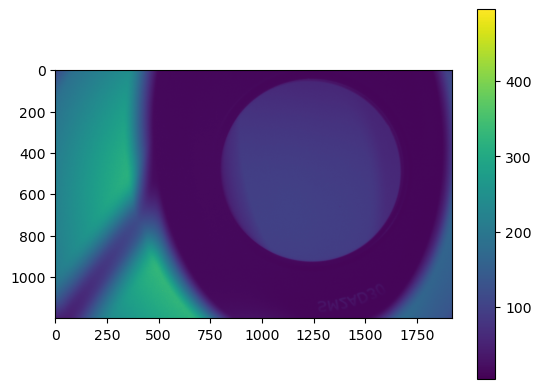

In [61]:
background = h5py.File('CLARA_experiments/YAGS/images/CLA-USR-DIA-CAM-01_2026-03-06_12-34-26UTC_20_images_full.hdf', 'r')
background_arr = np.array(background['Capture000001'])
plt.imshow(background_arr)
plt.colorbar()

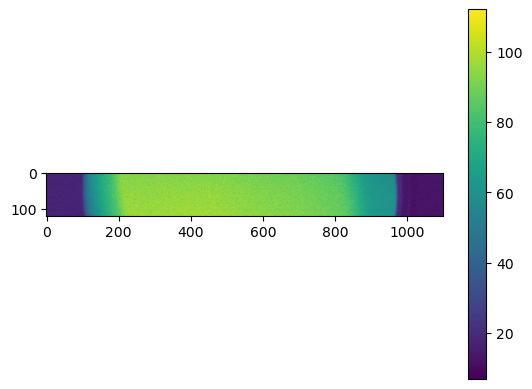

In [80]:
plt.imshow(background_arr[430:550, 700:1800])
plt.colorbar()

0.03170454545454545

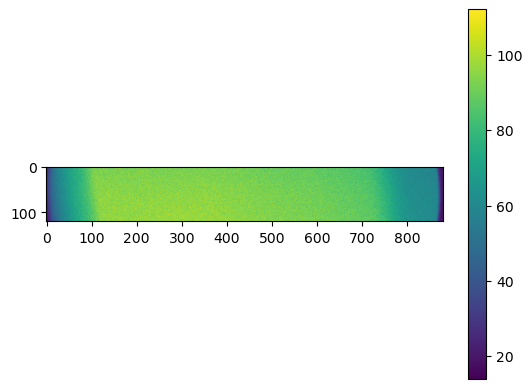

In [87]:
plt.imshow(background_arr[430:550, 800:1680])
plt.colorbar()
background_arr[430:550, 800:1680].shape #pixels for 27.9mm radius inner ring
pixel_calibration_YAG = 27.9/ (1680-800) #mm/pixel
pixel_calibration_YAG

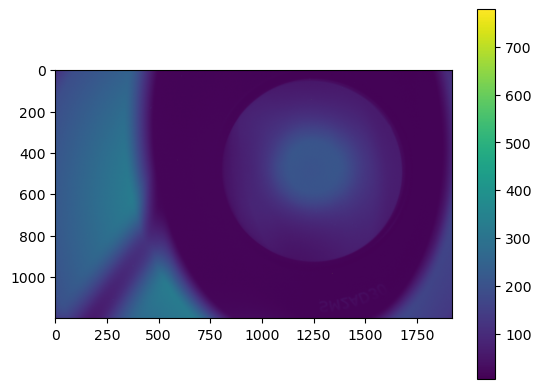

In [85]:
img1 = file['Capture000001']#[250:700,900:1650]
img1_arr = np.array(img1)
# combined = sum(file[key][250:700,900:1650] for key in file.keys())
average = sum(file[key][:] for key in file.keys())/len(file.keys())
plt.imshow(img1_arr)
plt.colorbar()

In [ ]:
background_arr 

array([[ 97, 110, 104, ...,  93,  92,  86],
       [104, 105, 105, ...,  86,  93,  92],
       [ 96, 101, 102, ..., 101,  93,  89],
       ...,
       [ 57,  60,  49, ..., 116, 119, 116],
       [ 60,  53,  52, ..., 115, 116, 120],
       [ 50,  50,  54, ..., 117, 115, 113]],
      shape=(1200, 1920), dtype=uint16)

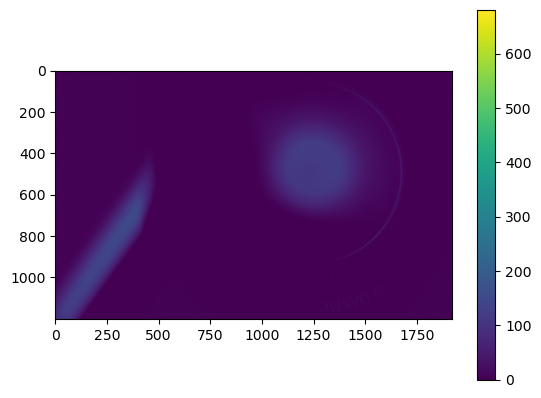

In [ ]:
net_intensity = img1_arr.astype(np.int32) - background_arr.astype(np.int32)
net_intensity = np.clip(net_intensity, 0, None) #remove negative values
plt.imshow(net_intensity)
plt.colorbar()

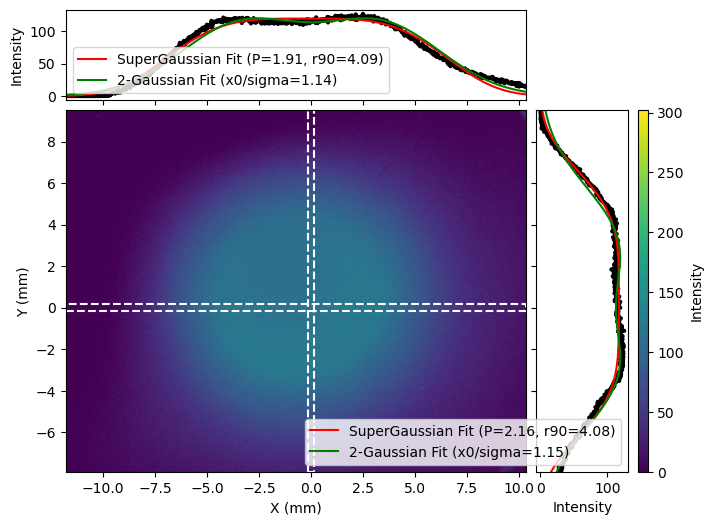

In [147]:
plot_dose1(net_intensity[200:750,900:1600],"YAG")
# plot_dose11(average[250:700,1000:1550],"YAG")
pixel_calibration = 0.08467  # mm/pixel
y,x = np.arange(average[250:700,1000:1550].shape[0])* pixel_calibration_YAG, np.arange(average[250:700,1000:1550].shape[1])* pixel_calibration_YAG
# print(x,y)
# plot_dose(average[250:700,1000:1550],x,y,strip_width=5, centred=False)


In [ ]:

# def beam_area(img, fraction, center):
#     peak_val = np.nanmax(img)
#     threshold = fraction * peak_val

#     # mask of pixels above threshold
#     mask = img >= threshold

#     # keep image shape (better for geometry)
#     new_img = np.zeros_like(img)
#     new_img[mask] = img[mask]

#     # coordinates
#     y, x = np.indices(img.shape)

#     cy, cx = center
#     r = np.sqrt((x - cx)**2 + (y - cy)**2)

#     # mean radius of beam region
#     r_mean = np.mean(r[mask])

#     return new_img, r_mean

In [8]:
means = []
stds = []

for key in sorted(file.keys()): #guarantees they are processed in numerical order
    img = file[key][:]#[250:700, 900:1650]

    y, x = np.indices(img.shape)

    cx, cy = beam_centroid(img)

    # squared distance (faster than sqrt)
    r2 = (x - cx)**2 + (y - cy)**2

    R60 = beam_area(img, 0.6, cx, cy)

    mask = r2 <= R60**2

    mean_dose = np.nanmean(img[mask])
    std_dose = np.nanstd(img[mask])

    means.append(mean_dose)
    stds.append(std_dose)

TypeError: beam_area() takes 3 positional arguments but 4 were given

In [ ]:
means,stds

([np.float64(187.22455969050736),
  np.float64(200.07234212199248),
  np.float64(201.46568111839966),
  np.float64(171.9484591828938),
  np.float64(205.05865698729582),
  np.float64(158.6864856889938),
  np.float64(189.88238814780806),
  np.float64(203.7654170321498),
  np.float64(206.00607413370412),
  np.float64(204.9720167607943)],
 [np.float64(23.67840253648773),
  np.float64(13.38530854621843),
  np.float64(6.396776750246859),
  np.float64(29.55884864434986),
  np.float64(5.96195198886665),
  np.float64(38.074841465611904),
  np.float64(20.451868828207257),
  np.float64(6.22173967849886),
  np.float64(6.170794705388602),
  np.float64(5.964272412747059)])

In [9]:

masked_img = np.zeros_like(img)
masked_img[mask] = img[mask]

# plt.imshow(masked_img)
plt.imshow(img)
plt.contour(mask, colors='white')

NameError: name 'mask' is not defined

uint16
(3659, 4950, 3)
3242 65535


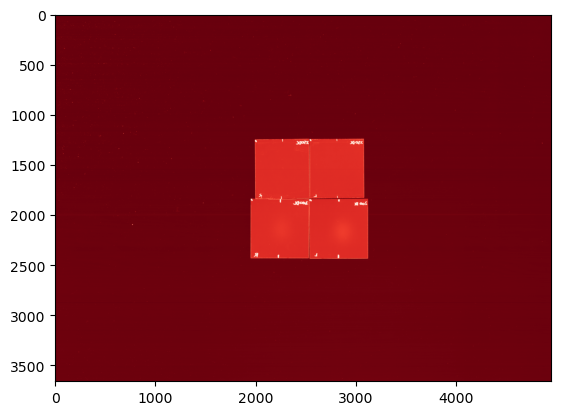

In [ ]:
channel = 0
if channel == 1:
    cmap = 'Greens'

elif channel ==0:
    cmap = "Reds"

arr = tiff.imread("CLARA_experiments/CLARA_films/Film Scans/DC/CLARA_DC_250_200_MeV_2026_12_03.tif")
print(arr.dtype)
print(arr.shape)
print(arr.min(), arr.max())
plt.imshow(arr[:,:,channel],cmap=cmap)

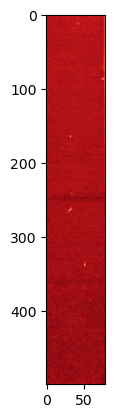

In [161]:
film_no_dose = tiff.imread("CLARA_experiments/CLARA_films/Film Scans/DC/CLARA_DC_250_200_MeV_2026_12_03.tif")
plt.imshow(film_no_dose[1300:1800,3000:3080,channel],cmap = cmap)#strip of top right film right 



(np.uint16(46955), np.uint16(3242))

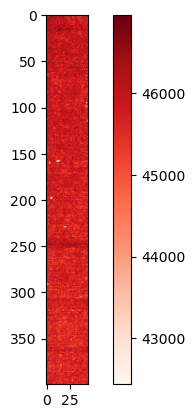

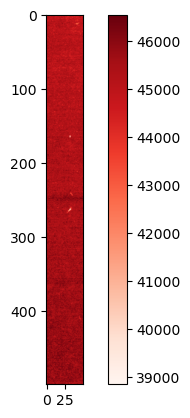

In [167]:
plt.imshow(film_no_dose[1300:1700,2005:2050,channel],cmap=cmap) #strip of top left film left
plt.colorbar()
plt.figure()
plt.imshow(film_no_dose[1300:1800,3000:3050,channel],cmap = cmap) #strip of top right film right 
plt.colorbar()
np.max(film_no_dose[1300:1700,2005:2050,channel]), np.min(film_no_dose)

45743.0


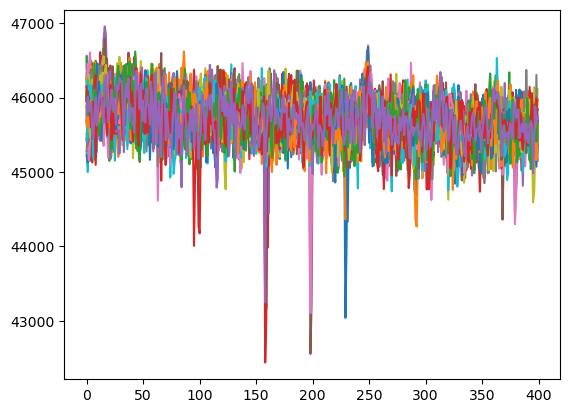

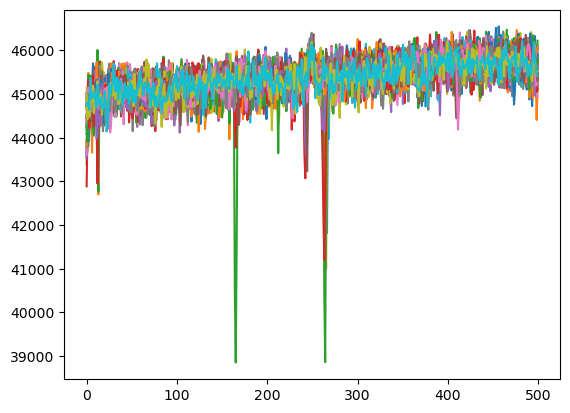

In [168]:
plt.plot(film_no_dose[1300:1700,2005:2050,channel])#right strip
print(np.median(film_no_dose[1300:1700,2005:2050,channel]))
plt.figure()
plt.plot(film_no_dose[1300:1800,3000:3050,channel]) #left strip

In [170]:
OD0_green = -np.log(np.median(film_no_dose[1300:1700,2005:2010,1])/65535)
OD0_red = -np.log(np.median(film_no_dose[1300:1700,2005:2010,0])/65535)
OD0_green,OD0_red

(np.float64(0.41037528937056844), np.float64(0.35893364827233415))

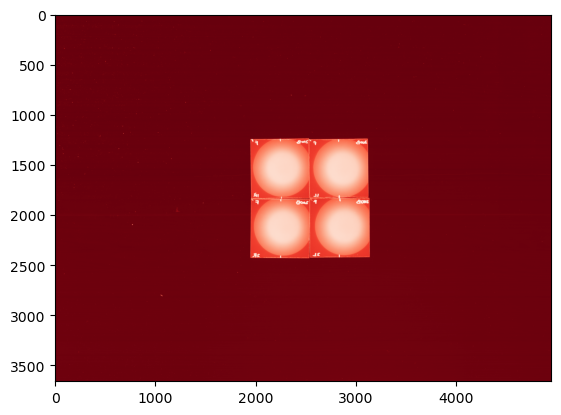

In [23]:
filename = 'CLARA_200B_F_2026_12_03'
films = tiff.imread(f"CLARA_experiments/CLARA_films/Film Scans/200B/{filename}.tif")
#("CLARA_experiments/CLARA_films/Film Scans/250S/CLARA_250S_B_2026_12_03.tif")
plt.imshow(films[:,:,channel],cmap = cmap)
# films.show()  # display image
# flipped_h = films.transpose(Image.FLIP_LEFT_RIGHT)

film_array = np.array(films)

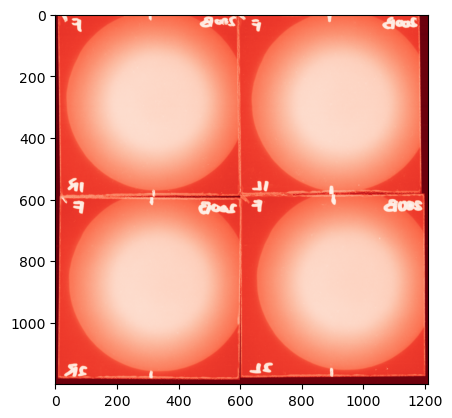

In [24]:
plt.imshow(film_array[1250:2450,1940:3150,channel],cmap=cmap)

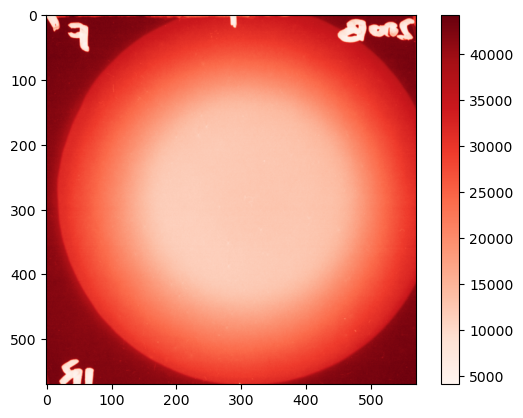

In [149]:
film1 = film_array[1250:1820,1960:2530,channel]
film2 = film_array[1250:1820,2560:3120,channel]
film3 = film_array[1850:2420,1960:2520,channel]
film4 = film_array[1840:2420,2550:3130,channel]



plt.imshow(film1,cmap=cmap)
plt.colorbar()


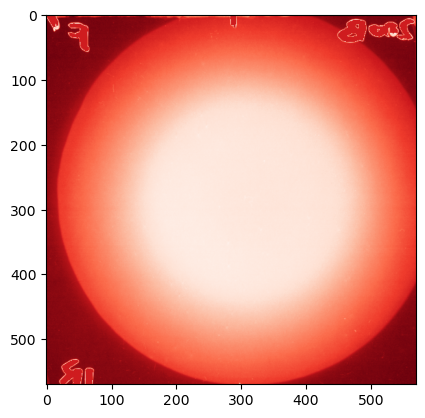

In [ ]:
# removing low pixel values in corners and strip regions (from marker labeling)
from scipy import ndimage as ndi
h, w = film1.shape[:2]
corner_h = 70
corner_w = 15

mask[:corner_h, :corner_w] = True
mask[:30, w//2-10:w//2+10] = True
mask[:corner_h, w-corner_w:] = True
mask[h-corner_h:, :corner_w] = True
mask[h-corner_h:, w-corner_w:] = True

film1[(mask) & (film1 < 12000)] = 35000
plt.imshow(film1,cmap=cmap)

In [ ]:
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film1.npy', film1)
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film2.npy', film2)
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film3.npy', film3)
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film4.npy', film4)

In [137]:
def dose_CLARA(PV,nOD0, channel):
    if channel ==0:
        a, b, c = 3.27, 16.9, -3.28
    elif channel ==1:
        a, b, c = 8.2, 10.9, -8.2
    elif channel ==2:
        a, b, c = 21.0, 14.0, -21.0

    OD = -np.log(PV/65535)
    nOD = OD - nOD0

    return a * (b*nOD) + c



In [138]:
print(dose_CLARA(film1, OD0_red, channel))



[[74.43619688 76.30117272 78.12105179 ... 13.83875128 15.60099543
  14.02489761]
 [75.74981051 78.40813296 80.02570209 ... 18.2797912  14.49650766
  13.71500116]
 [72.43303524 79.68478183 80.18552084 ... 17.25996564 13.70813427
  13.11395782]
 ...
 [ 0.9718862   1.38788302  0.67277705 ... -2.62222031 -2.46359125
  -2.63243883]
 [ 1.81810841  1.44835334  1.2287777  ... -3.44889221 -3.11059005
  -3.06498829]
 [ 2.02892498  1.28358987  1.81810841 ... -3.94002188 -3.18650947
  -2.8465923 ]]


In [139]:
film1.min(), film1.max()

(np.uint16(4052), np.uint16(44305))

1.0 -0.048396788723853675


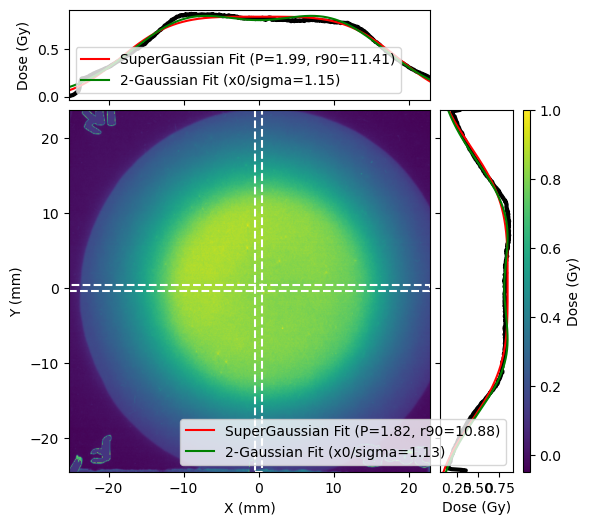

In [157]:
dose_rel = dose_CLARA(film1, OD0_red, channel)/np.max(dose_CLARA(film1, OD0_red, channel))
plot_dose1(dose_rel,"RCF")
print((dose_rel).max(), (dose_rel).min())

In [89]:
def dose_CLEAR(PV, nOD0, channel):
    if channel == 0:
        a, b, c = 4.6093, 0.1574, 4.6606
    elif channel == 1:
        a, b, c = 7.9162, 0.0418, 7.9213
    elif channel == 2:
        a, b, c = 23.5294, 0.1614, 23.2037

    # if channel == 0:
    #      a, b, c = 4.5211, 0.1609, 4.5522
    # elif channel == 1:
    #     a, b, c = 7.9284, 0.0414, 7.9364
    # elif channel == 2:
    #     a, b, c = 24.0703, 0.1513, 23.7625



    OD = -np.log(PV / 65535)
    nOD = OD - nOD0

    exp_term = np.exp(-nOD)
    return (a - c * exp_term) / (exp_term - b)


print(dose_CLEAR(film1, OD0_red, channel))
print((dose_CLEAR(film1, OD0_red, channel)).max(), (dose_CLEAR(film1, OD0_red, channel)).min())

[[45.68376547 51.34178471 57.98696937 ...  2.46010735  2.76037005
   2.49111108]
 [49.56156445 59.15894424 66.53560973 ...  3.24732413  2.57040401
   2.43958711]
 [40.59749598 64.86148451 67.34477428 ...  3.05740716  2.43845056
   2.34094477]
 ...
 [ 0.66137951  0.71036371  0.62648403 ...  0.25931569  0.27629383
   0.25822434]
 [ 0.76158353  0.71752833  0.69156635 ...  0.17193069  0.20747117
   0.21228514]
 [ 0.78689232  0.69803332  0.76158353 ...  0.12087087  0.19946901
   0.23541721]]
11334.437333009831 -499148.30585105735


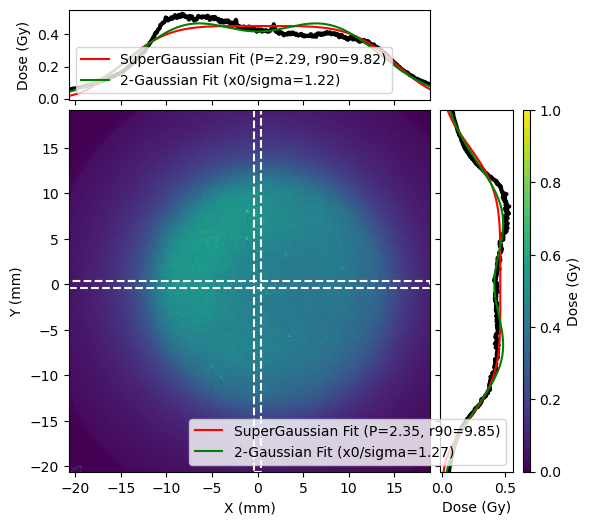

In [158]:
plot_dose1(dose_CLEAR(film1[50:-50,50:-50], OD0_red, channel)/np.max(dose_CLEAR(film1[50:-50,50:-50], OD0_red, channel)),"RCF")

In [56]:
def dose_CLEAR_poly(PV, nOD0, channel):
    
    # Polynomial coefficients (p4 → p0)
    if channel == 0:  # red
        coeffs = [9.56465954, -10.0096134, 10.1602326, 4.12083547, 0.00726233]
    elif channel == 1:  # green
        coeffs = [1.46014808, 0.98750624, 4.57336183, 8.33547864, -0.01277002]
    elif channel == 2:  # blue
        coeffs = [129.62111299, -72.99599522, 30.51809185, 28.99559952, 0.33870407]
    else:
        raise ValueError("channel must be 0 (red), 1 (green), or 2 (blue)")

    # Convert to OD → nOD
    OD = -np.log(PV / 65535)
    nOD = OD - nOD0

    # Evaluate polynomial
    return np.polyval(coeffs, nOD)

print(dose_CLEAR_poly(film1, OD0_red, channel))
print((dose_CLEAR_poly(film1, OD0_red, channel)).max(), (dose_CLEAR_poly(film1, OD0_red, channel)).min())

[[39.17860519 42.22348379 45.39681185 ...  2.44789037  2.74988304
   2.4791309 ]
 [41.30194445 45.91629416 48.94286476 ...  3.23706191  2.55896889
   2.42720615]
 [36.1295668  48.29072544 49.25124147 ...  3.04741397  2.42606036
   2.32769646]
 ...
 [ 0.64166229  0.68885462  0.60824487 ...  0.27029342  0.28522832
   0.26933623]
 [ 0.73852433  0.69578325  0.67070744 ...  0.194795    0.22521328
   0.22936459]
 [ 0.76317944  0.67694559  0.73852433 ...  0.15184089  0.21832881
   0.24941248]]
257.53281936305376 0.1518408944265716


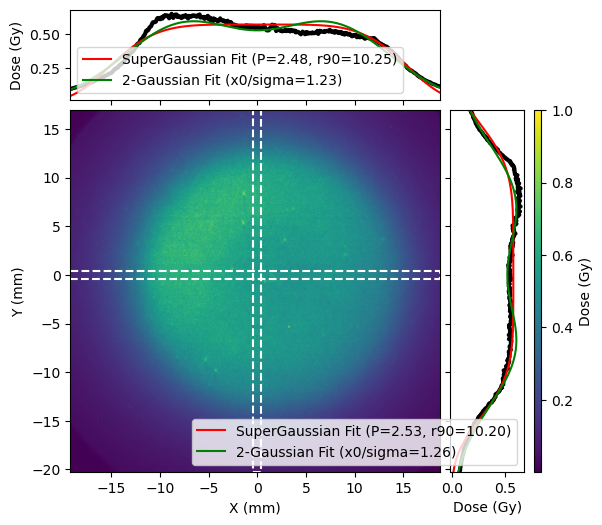

In [159]:
plot_dose1(dose_CLEAR_poly(film1[50:-80,70:-50], OD0_red, channel)/np.max(dose_CLEAR_poly(film1[50:-80,70:-50], OD0_red, channel)),"RCF")

checking code with CLEAR HUG films

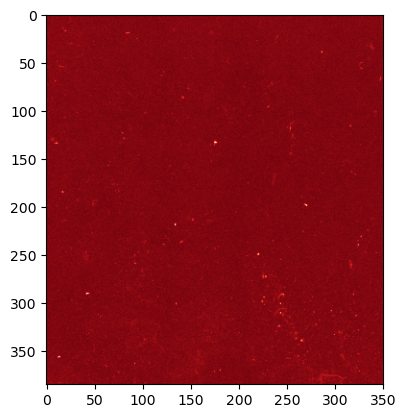

In [105]:
film_no_dose = tiff.imread("ZFE_28_10_2025_24h/J_035.tif")
plt.imshow(film_no_dose[50:-50, 30:-40, channel], cmap = cmap)

In [106]:

OD0_green = -np.log(np.median(film_no_dose[50:-50, 30:-40, 1])/65535)
OD0_red = -np.log(np.median(film_no_dose[50:-50, 30:-40, 0])/65535)
OD0_green,OD0_red

(np.float64(0.42962741958434625), np.float64(0.40343010071779056))

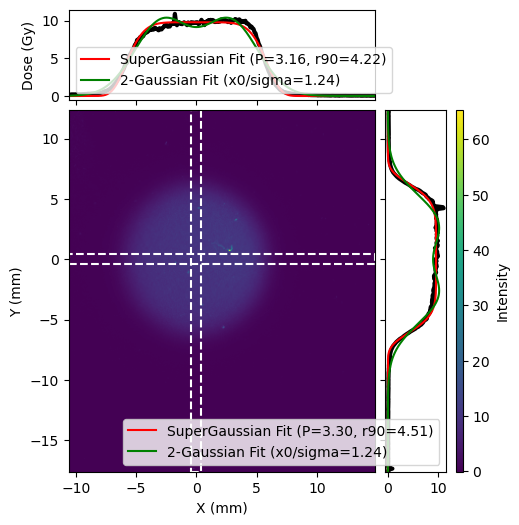

In [109]:
film_dummy = np.array(tiff.imread("ZFE_28_10_2025_24h/F_001.tif"))
plot_dose1(dose_CLEAR_poly(film_dummy[50:-80,70:-50,channel], OD0_red, channel),"RCF")

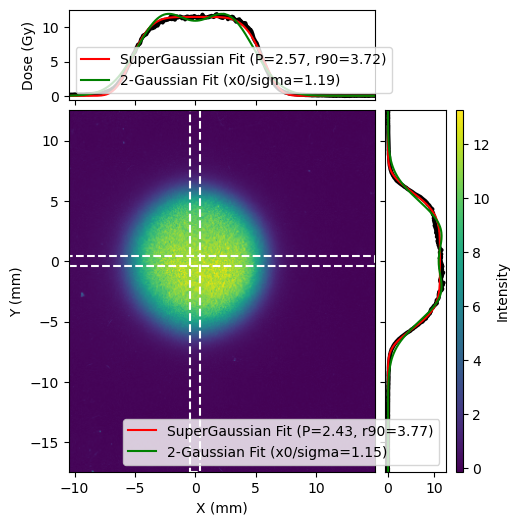

In [111]:
film_dummy = np.array(tiff.imread("ZFE_28_10_2025_24h/F_009.tif"))
plot_dose1(dose_CLEAR(film_dummy[50:-80,70:-50,channel], OD0_red, channel),"RCF")